## <b>Sinusoidal Experiments</b>

### Study Motivation:

In this study, we compare **SWIM-PDE** and **SWIM-PDE-DD (Domain Decomposed SWIM-PDE)** function representation performances using the one-dimensional sinusoidal problems with different frequency characteristics under function approximation setup. Here the aim is not solving the PDEs by evaluating higher order operators, instead we pretend as we know the exact solution and try to represent this solution by our SWIM network models as <b>u(t) = u_true(t)</b>, where <b>u(t)</b> is our network prediction for given input timestamps under given boundary conditions.

<b>Note:</b> In the regular PDE solving setup we have to approximate the <b>f(x)</b> (RHS equation in the given problem; <b>0</b> in this case) by evaluating the each individual operators in RHS of the equation. 

---
### Parametric Setup:

All models are trained with <b>150</b> collocation points and tested with <b>300</b> points evenly spaced on the domain <b>[0, 1]</b>. The <b>SWIM-PDE-DD</b> divides this domain into <b>5 equally spaced</b> subdomains for the first experiment and <b>20 equally spaced</b> subdomains for the other two experiments, using <b>0.5</b> overlapping ratio, ensuring a moderate level of overlap between window functions. For the <b>SWIM-PDE-DD</b>, each subdomain is evaluated by a SWIM network with <b>8</b> basis function. The <b>SWIM-PDE</b> uses one SWIM network with <b>8 x number of subdomains</b> basis functions to be able to provide same capacity with an equal chance of capturing the solution. All models were trained using tanh basis functions.

---

### Loss Function:
We evaluate each model using the L1 test loss:
$$
{\text{MAE}} = {\frac{1}{N_X} \sum_{i=1}^{N_X} \left| u_{\text{exact}}(x^{i}_{\text{test}}) - u_{NN}(x^{i}_{\text{test}}) \right|}
$$


where $\{ x^i_{\text{test}} \}_{i=1}^{N_X}$ is the set of test points, $u_{\text{exact}}$ is the exact solution, and $u_{NN}$ is the SWIM network approximation of $u_{\text{exact}}$.

---


#### Common Module Imports

In [1]:
import os
import sys
root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
print(root)
sys.path.append(root)

import time
from functools import partial
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

c:\Users\dogak\OneDrive\Belgeler\swim-pde-thesis


## <b>1. First Order Sinusoidal Problems</b>

#### <u>Problem 1</u>: 
This problem is defined for 'Low-frequency' and 'High-frequency' experiments as following:
$$
\frac{du}{dx} = \cos(\omega x), \quad x \in [-2\pi, 2\pi],
$$
$$
\quad u(0) = 0,
$$
where $x$ is the independent variable and $w$ is a scalar represents frequency of the solution. 
The exact solution to the differential equation is:
$$
u(x) = \frac{1}{\omega} \sin(\omega x).
$$

#### <u>Problem 2</u>:
This following problem is selected for testing the function approximation capabilities of SWIM models on a multi-scale problem. This is the extension of the above problem where difficulty of the problem is increased by including multi-scale frequency components in its solution.

$$
\frac{du}{dx} = \omega_1 \cos(\omega_1 x) + \omega_2 \cos(\omega_2 x), \quad x \in [-2\pi, 2\pi],
$$
$$
\quad u(0) = 0,
$$
where $x$ is the independent variable and $\omega_1$ and $\omega_2$ are scalars that inject multi-scale frequency components into the solution. 
The exact solution to the differential equation is:
$$
u(x) = \sin(\omega_1 x) + \sin(\omega_2 x)
$$



We define the explained problems programmatically as following:

In [2]:
# Neural operator definition for the problem
from dataclasses import dataclass
import numpy.typing as npt
from swimpde_jax.abstract import Ansatz, StaticEquation


@dataclass
class FirstOrder(StaticEquation):
    """A representer of the first order derivative

    du/dx = 0
    """

    def equation_operator(self, ansatz: Ansatz, points: npt.ArrayLike) -> npt.ArrayLike:
        u_x = ansatz.transform(points, operator="gradient").squeeze()
        return u_x
 
    def equation_bias(self) -> float:
        return 0

In [3]:
# Target functions and problem parameters definition
def prob1_sol(x: npt.ArrayLike, w: int):
    """
    Analytical solution of du/dx = cos(wx) when u(0) = 0 where x in [-2*pi, 2*pi].

    Parameters:
        x (array-like): independent parameter
        w (float): frequency

    Returns:
        u (array-like or float): Analytical solution of the problem 1.
    """
    return ((1 / w) * (np.sin(w * x)))

def prob1_forcing(x: npt.ArrayLike, w:int):
    return np.cos(w * x)

def prob2_sol(x: npt.ArrayLike, w1: int, w2: int):
    """
    Solution of du/dx = w1*cos(w1*x) + w2*cos(w2*x) when u(0) = 0 where x in [-2*pi, 2*pi]


    Parameters:
        x (array-like): independent parameter
        w1 (float): first frequency component
        w2 (float): second frequency component

    Returns:
        u (array-like or float): Analytical solution of the problem 2.
    """
    return np.sin(w1 * x) + np.sin(w2 * x)

def prob2_forcing(x: npt.ArrayLike, w1:int, w2:int):
    return w1 * np.cos(w1 * x) + w2 * np.cos(w2 * x)

### <b>1.1. Low Frequency Experiment</b>

For the low frequency case the domain <b>$x \in [-2\pi, 2\pi]$</b>, divided into <b>n = 5</b> overlapping subdomains with overlapping ratio <b>1.9</b> for SWIM-PDE-DD. In each subdomain network <b>3</b> <b>tanh</b> basis function is used for <b>SWIM-PDE-DD</b>, whereas for regular <b>SWIM-PDE</b> model we also used same type and number of basis functions in single SWIM network. The models are trained using <b>200 regularly spaced</b> training points across the domain, and tested using <b>1000 regularly spaced</b> test points in the domain.

In [4]:
# Experiment definition
W = 1   # low frequency
RANDOM_STATE = 17 # for result reproducibility

# Dataset definition
NUM_TRAIN_POINTS = 200
NUM_TEST_POINTS = 1000

# Domain definition
SPAN = (-2*np.pi, 2*np.pi)

# randomness setting
rng = np.random.default_rng(seed=RANDOM_STATE)

# Dataset creation
exp1_train_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TRAIN_POINTS).reshape(-1, 1)
exp1_train_targets = prob1_sol(exp1_train_inputs, w=W)

exp1_test_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TEST_POINTS).reshape(-1, 1)
exp1_test_targets = prob1_sol(exp1_test_inputs, w=W)

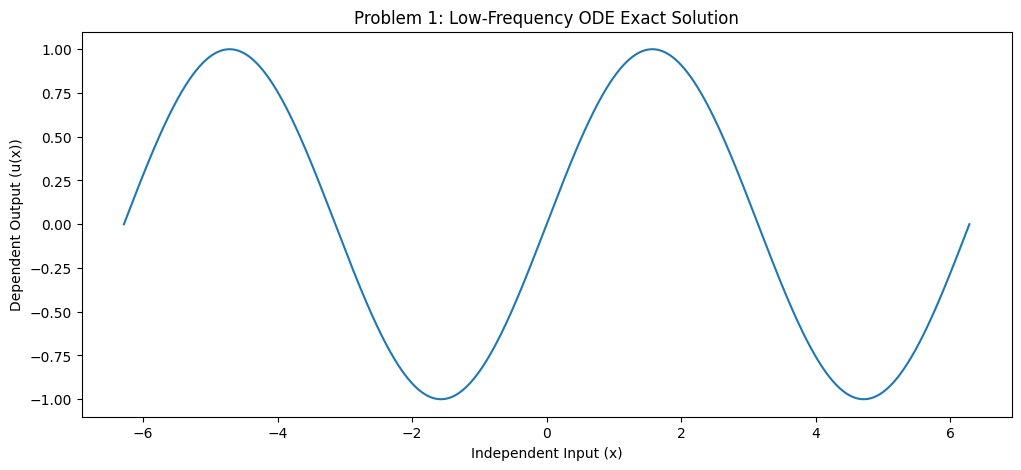

In [5]:
# Plotting exact solution
plt.subplots(figsize=(12, 5))
plt.plot(exp1_test_inputs, exp1_test_targets)
plt.xlabel('Independent Input (x)')
plt.ylabel('Dependent Output (u(x))')
plt.title('Problem 1: Low-Frequency ODE Exact Solution')
plt.show()

##### Model Specific Parameter Definitions

In [6]:
# Common parameter definitions
ACTIVATION_FUNCTION = "tanh"
PARAMETER_SAMPLER = "tanh"
REGULARIZATION_SCALE = 1e-12
SWIM_SVD_CUTOFF= 1e-12
WINDOW_FN = "gaussian"

# SWIM-PDE-DD specific parameter definitions
SWIM_PDE_DD_NUM_BASIS = 3
SWIM_PDE_DD_NUM_SUBDOMAINS = 5
SWIM_PDE_DD_OVERLAPPING_RATIO = 1.9
SWIM_PDE_DD_SOLVER = "lstsq"

# SWIM-PDE specific parameter definitions
SWIM_PDE_NUM_BASIS =  SWIM_PDE_DD_NUM_BASIS * SWIM_PDE_DD_NUM_SUBDOMAINS


##### SWIM-PDE Training and Inference

In [7]:
from swimpde_jax.domain import Domain
from swimpde_jax.solver import StaticSolver
from swimpde_jax.boundary import ZeroDirichlet
from swimpde_jax.ansatz import BasicAnsatz

In [8]:
# Domain Definition
boundary_mask = ((exp1_train_inputs == exp1_train_inputs[0]) | (exp1_train_inputs == exp1_train_inputs[-1])).flatten()

domain = Domain(
        interior_points=exp1_train_inputs[~boundary_mask],
        boundary_points=exp1_train_inputs[boundary_mask],
    )


# Equation Definition
equation = FirstOrder()

# Forcing function and boundary condition definition
forcing_function = partial(prob1_forcing, w=W)
boundary_condition = ZeroDirichlet()

# Ansatz definition 
ansatz = BasicAnsatz(
    n_basis=SWIM_PDE_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    parameter_sampler=PARAMETER_SAMPLER,
)

# Solver definition
swimpde_solver = StaticSolver(
    domain=domain,
    ansatz=ansatz,
    boundary_condition=boundary_condition,
    equation=equation,
    f=forcing_function, 
    regularization_scale=REGULARIZATION_SCALE,
)

# Training
swimpde_solver.fit()

# Inference
exp1_swimpde_prediction = swimpde_solver.evaluate(exp1_test_inputs).reshape(NUM_TEST_POINTS, -1)

##### SWIM-PDE-DD Training and Inference

In [9]:
from swimpde_jax.domain import DecomposedDomain
from swimpde_jax.solver import DomainDecomposedStaticSolver
from swimpde_jax.ansatz import DecomposedBasicAnsatz
from swimpde_jax.boundary import ZeroDirichlet

In [10]:

# Domain Definition
boundary_mask = ((exp1_train_inputs == exp1_train_inputs[0]) | (exp1_train_inputs == exp1_train_inputs[-1])).flatten()

domain = DecomposedDomain(
        interior_points=exp1_train_inputs[~boundary_mask],
        boundary_points=exp1_train_inputs[boundary_mask],
        overlap_ratio=SWIM_PDE_DD_OVERLAPPING_RATIO,
        num_partition_per_dim=SWIM_PDE_DD_NUM_SUBDOMAINS,
        window_fn=WINDOW_FN,
    )

# Equation Definition
equation = FirstOrder()

# Forcing function and boundary condition definition
forcing_function = partial(prob1_forcing, w=W)
boundary_condition = ZeroDirichlet()

# Ansatz definition 
ansatz = DecomposedBasicAnsatz(
    n_basis=SWIM_PDE_DD_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    svd_cutoff=SWIM_SVD_CUTOFF,
)

# Solver definition
swimpde_dd_solver = DomainDecomposedStaticSolver(
        domain=domain,
        ansatz=ansatz,
        boundary_condition=boundary_condition,
        equation=equation,
        f=forcing_function, 
        regularization_scale=REGULARIZATION_SCALE,
        solver=SWIM_PDE_DD_SOLVER,
        use_disk=False,
    )

# Training
swimpde_dd_solver.fit()

# Inference
exp1_swimpde_dd_prediction, exp1_swimpde_dd_level_based_predictions, exp1_swimpde_dd_local_network_predictions = swimpde_dd_solver.evaluate(exp1_test_inputs)
exp1_swimpde_dd_prediction = exp1_swimpde_dd_prediction.reshape(NUM_TEST_POINTS, -1)

Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 1/1 [00:01<00:00,  1.01s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


#### Final Prediction Comparison

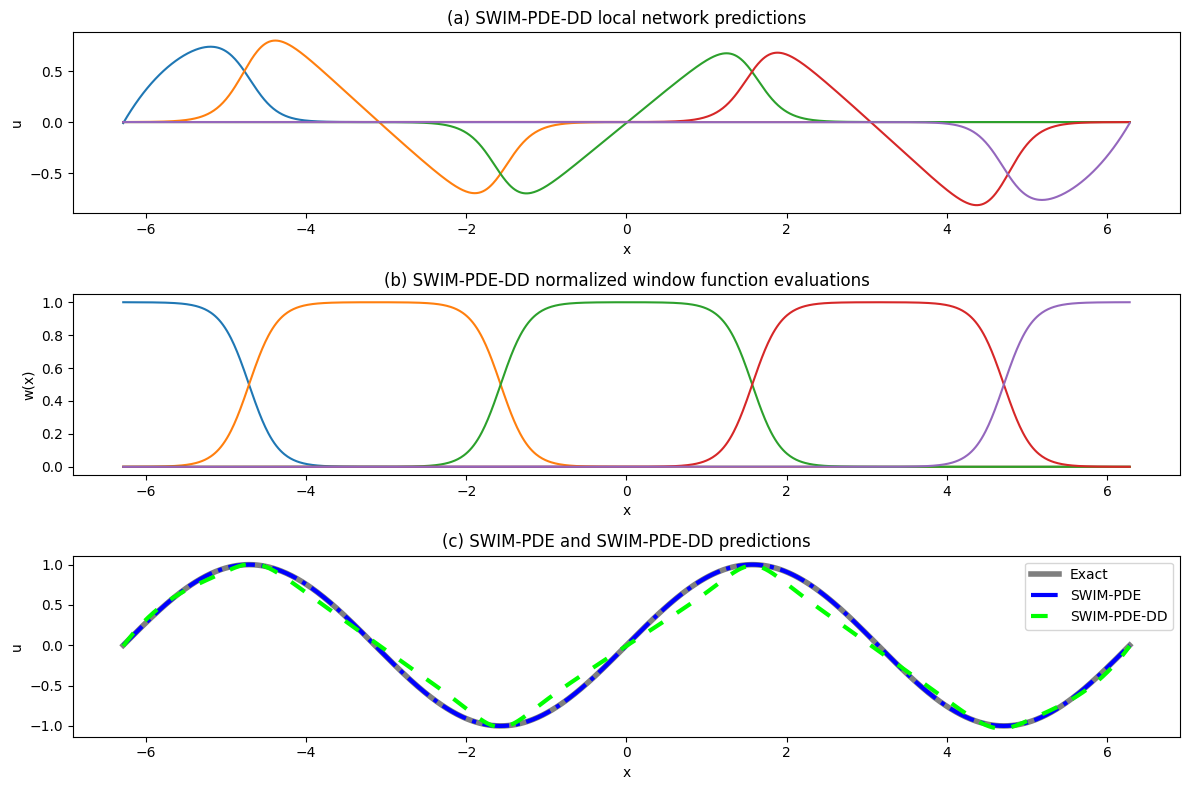

In [11]:
# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
axs = axs.flatten()

# Subplot (a): Individual networks
local_predictions = exp1_swimpde_dd_local_network_predictions[0]
for local_prediction in local_predictions:
    axs[0].plot(exp1_test_inputs, local_prediction)
    axs[0].set_title("(a) SWIM-PDE-DD local network predictions")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("u")
    
# Subplot (b): Window functions
window_evals = [subdomain.window_fn.f(exp1_test_inputs) for subdomain in domain.subdomains]
normalizer = np.sum(np.array(window_evals), axis=0)
for window_eval in window_evals:
    axs[1].plot(exp1_test_inputs, window_eval/normalizer)
    axs[1].set_title("(b) SWIM-PDE-DD normalized window function evaluations")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("w(x)")

# Subplot (c): Full solution vs exact
axs[2].plot(exp1_test_inputs, exp1_test_targets, '-', label='Exact', color='black', linewidth=4, alpha=0.5)
axs[2].plot(exp1_test_inputs, exp1_swimpde_prediction, '-.', label='SWIM-PDE', color='blue', linewidth=3)
axs[2].plot(exp1_test_inputs, exp1_swimpde_dd_prediction, '-', dashes=(4, 4), label='SWIM-PDE-DD', color='lime', linewidth=3)
axs[2].set_title("(c) SWIM-PDE and SWIM-PDE-DD predictions")
axs[2].set_xlabel("x")
axs[2].set_ylabel("u")
axs[2].legend()

plt.tight_layout()
plt.show()

In [12]:
# Mean L1 Loss (Mean Absolute Error = MAE) comparison
from sklearn.metrics import mean_absolute_error
exp1_swimpde_loss = mean_absolute_error(exp1_test_targets, exp1_swimpde_prediction)
exp1_swimpde_dd_loss = mean_absolute_error(exp1_test_targets, exp1_swimpde_dd_prediction)

print("SWIM-PDE Low-Frequency MAE = ", exp1_swimpde_loss)
print("SWIM-PDE-DD Low-Frequency MAE =", exp1_swimpde_dd_loss)
print("Number of partition =", SWIM_PDE_DD_NUM_SUBDOMAINS)
print("Estimated number of training points per subdomain = ", NUM_TRAIN_POINTS/SWIM_PDE_DD_NUM_SUBDOMAINS)

SWIM-PDE Low-Frequency MAE =  0.00015493639584326953
SWIM-PDE-DD Low-Frequency MAE = 0.08033075358866534
Number of partition = 5
Estimated number of training points per subdomain =  40.0


#### Evaluation

As we can see from the results, since we try to approximate a relatively simple solution which contains same low frequency content across the whole domain, both models are able to approximate the solution quite well. However, still the approximation accuracy of the SWIM-PDE-DD model which uses partitioning is higher than the SWIM-PDE model. From the figure above, we can see each individual network predictions after the weighting with corresponding window function evaluation is applied in the first subplot. In the second subplot we can see how the normalized window function evaluations cover the entire domain. Finally in the third subplot we can see the global predictions of both models. The global prediction of the SWIM-PDE-DD model is obtained summing of the weighted local network predictions by their normalized window function evaluations over the whole domain. This approach produces a better approximation result by blending each local network prediction which can capture the local dynamics better smoothly make use of the window functions.

<b>Note!</b>: Adding more subdomains does not yield lower accuracy every time. If we increase the number of subdomains, number of collocation points within each subdomains reduce. This causes poorer accuracy when we compare a SWIM-PDE-DD with a regular SWIM-PDE with the same capacity. For example, when we use 5 subdomains the SWIM-PDE-DD approximates the function better, but when we increase the number of subdomains to 20, then the SWIM-PDE-DD prediction accuracy remains below than the regular SWIM-PDE model due to 2 reasons:
1. We provide enough capacity to SWIM-PDE to approximate the function better.
2. Each subdomains getting lower number of collocation points for SWIM-PDE-DD, which yields lower quality initialization for each subnetwork due to lack of sampling points.

### <b>1.2. High Frequency Experiment</b>

For the high frequency case we only change some parameters to highlight the benefits of using domain decomposition better. As a first change, we set the frequency $\omega = 15$ to have a solution with high frequency content, which is more challenging than low frequency case to approximate. We also increased the number of <b>evenly sampled</b> training and test points to <b>200 x 15 = 3000</b> and <b>5000</b> for better sampling from a highly oscillatory function.

In [13]:
# Experiment definition
W = 15   # high frequency
RANDOM_STATE = 17 # for result reproducibility

# Dataset definition
NUM_TRAIN_POINTS = 3000
NUM_TEST_POINTS = 5000

# Domain definition
SPAN = (-2*np.pi, 2*np.pi)

# randomness setting
rng = np.random.default_rng(seed=RANDOM_STATE)

# Dataset creation
exp2_train_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TRAIN_POINTS).reshape(-1, 1)
exp2_train_targets = prob1_sol(exp2_train_inputs, w=W)

exp2_test_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TEST_POINTS).reshape(-1, 1) # shape (NUM_TEST_POINTS, 1)
exp2_test_targets = prob1_sol(exp2_test_inputs, w=W)

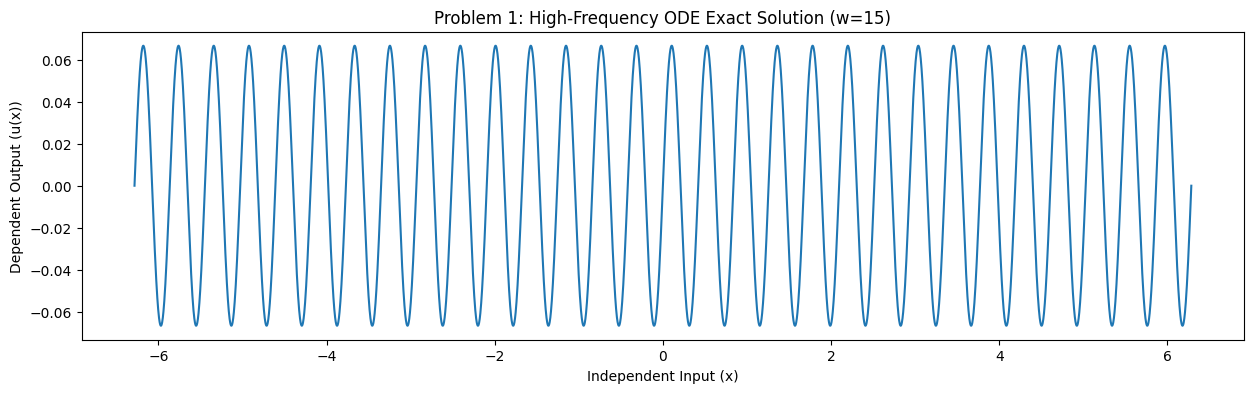

In [14]:
# Plotting exact solution
plt.figure(figsize=(15, 4))
plt.plot(exp2_test_inputs, exp2_test_targets)
plt.xlabel('Independent Input (x)')
plt.ylabel('Dependent Output (u(x))')
plt.title('Problem 1: High-Frequency ODE Exact Solution (w=15)')
plt.show()

##### Model Specific Parameter Definitions

In [15]:
# Common parameter definitions
ACTIVATION_FUNCTION = "tanh"
PARAMETER_SAMPLER = "random"
REGULARIZATION_SCALE = 1e-12
SWIM_SVD_CUTOFF= 1e-12

# SWIM-PDE-DD specific parameter definitions
SWIM_PDE_DD_NUM_BASIS = 8
SWIM_PDE_DD_NUM_SUBDOMAINS = 20
SWIM_PDE_DD_OVERLAPPING_RATIO = 1.9
SWIM_PDE_DD_SOLVER = "lstsq"

# SWIM-PDE specific parameter definitions
SWIM_PDE_NUM_BASIS =  SWIM_PDE_DD_NUM_BASIS * SWIM_PDE_DD_NUM_SUBDOMAINS


##### SWIM-PDE Training and Inference

In [16]:
# Domain Definition
boundary_mask = ((exp2_train_inputs == exp2_train_inputs[0]) | (exp2_train_inputs == exp2_train_inputs[-1])).flatten()
domain = Domain(
        interior_points=exp2_train_inputs[~boundary_mask],
        boundary_points=exp2_train_inputs[boundary_mask],
    )

# Equation Definition
equation = FirstOrder()

# Forcing function and boundary condition definition
forcing_function = partial(prob1_forcing, w=W)
boundary_condition = ZeroDirichlet() # u(0) = 0

# Ansatz definition 
ansatz = BasicAnsatz(
    n_basis=SWIM_PDE_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    parameter_sampler=PARAMETER_SAMPLER,
)

# Solver definition
swimpde_solver = StaticSolver(
    domain=domain,
    ansatz=ansatz,
    boundary_condition=boundary_condition,
    equation=equation,
    f=forcing_function, 
    regularization_scale=REGULARIZATION_SCALE,
)

# Training
swimpde_solver.fit()

# Inference
exp2_swimpde_prediction = swimpde_solver.evaluate(exp2_test_inputs).reshape(NUM_TEST_POINTS, -1)

##### SWIM-PDE-DD Training and Inference

In [17]:

# Domain Definition
boundary_mask = ((exp2_train_inputs == exp2_train_inputs[0]) | (exp2_train_inputs == exp2_train_inputs[-1])).flatten()

domain = DecomposedDomain(
        interior_points=exp2_train_inputs[~boundary_mask],
        boundary_points=exp2_train_inputs[boundary_mask],
        overlap_ratio=SWIM_PDE_DD_OVERLAPPING_RATIO,
        num_partition_per_dim=SWIM_PDE_DD_NUM_SUBDOMAINS,
        window_fn=WINDOW_FN,
    )

# Equation Definition
equation = FirstOrder()

# Forcing function and boundary condition definition
forcing_function = partial(prob1_forcing, w=W)
boundary_condition = ZeroDirichlet()

# Ansatz definition 
ansatz = DecomposedBasicAnsatz(
    n_basis=SWIM_PDE_DD_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    svd_cutoff=SWIM_SVD_CUTOFF,
    parameter_sampler=PARAMETER_SAMPLER
)

# Solver definition
swimpde_dd_solver = DomainDecomposedStaticSolver(
        domain=domain,
        ansatz=ansatz,
        boundary_condition=boundary_condition,
        equation=equation,
        f=forcing_function, 
        regularization_scale=REGULARIZATION_SCALE,
        solver=SWIM_PDE_DD_SOLVER,
        use_disk=False,
    )

# Training
swimpde_dd_solver.fit()

# Inference
exp2_swimpde_dd_prediction,  exp2_swimpde_dd_level_based_predictions, exp2_swimpde_dd_local_network_predictions = swimpde_dd_solver.evaluate(exp2_test_inputs)
exp2_swimpde_dd_prediction = exp2_swimpde_dd_prediction.reshape(NUM_TEST_POINTS, -1)

Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 1/1 [00:05<00:00,  5.21s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


#### Final Prediction Comparison

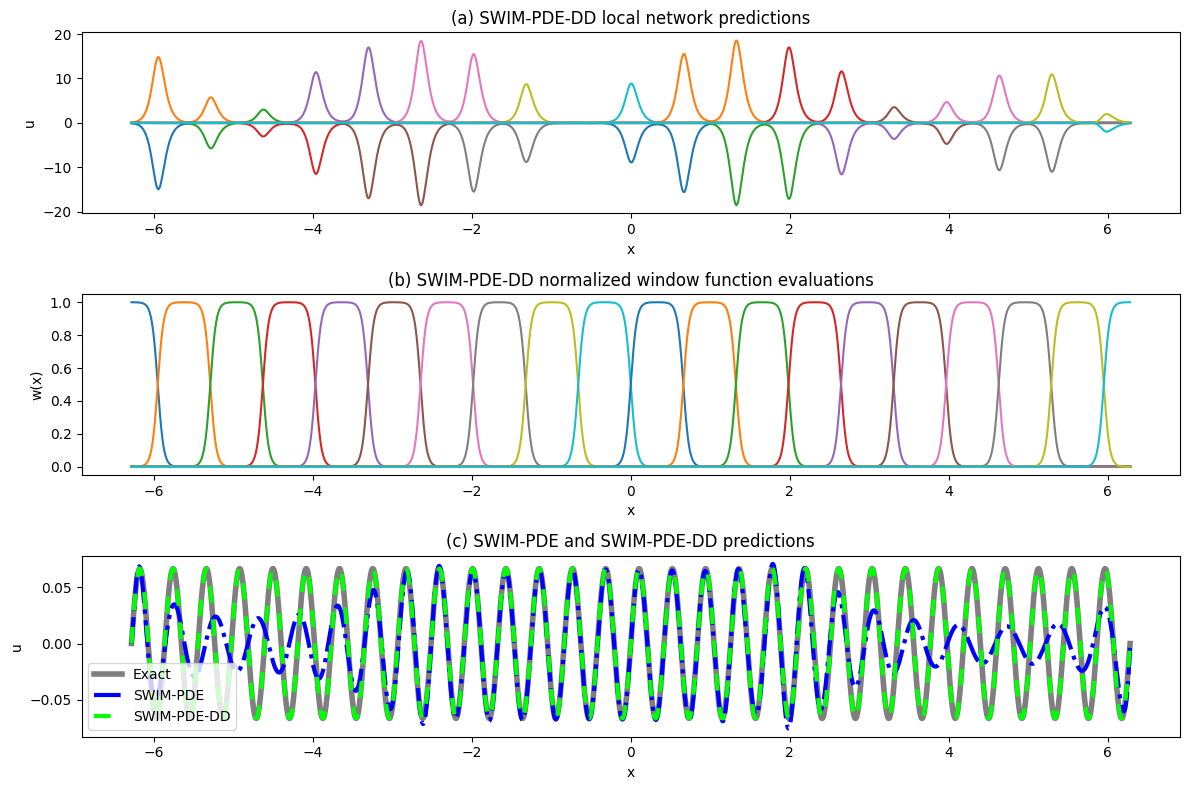

In [18]:
# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
axs = axs.flatten()

# Subplot (a): Individual networks
local_predictions = exp2_swimpde_dd_local_network_predictions[0]
for local_prediction in local_predictions:
    axs[0].plot(exp2_test_inputs, local_prediction)
    axs[0].set_title("(a) SWIM-PDE-DD local network predictions")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("u")
    
# Subplot (b): Window functions
window_evals = [subdomain.window_fn.f(exp2_test_inputs) for subdomain in domain.subdomains]
normalizer = np.sum(np.array(window_evals), axis=0)
for window_eval in window_evals:
    axs[1].plot(exp2_test_inputs, window_eval/normalizer)
    axs[1].set_title("(b) SWIM-PDE-DD normalized window function evaluations")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("w(x)")

# Subplot (c): Full solution vs exact
axs[2].plot(exp2_test_inputs, exp2_test_targets, '-', label='Exact', color='black', linewidth=4, alpha=0.5)
axs[2].plot(exp2_test_inputs, exp2_swimpde_prediction, '-.', label='SWIM-PDE', color='blue', linewidth=3)
axs[2].plot(exp2_test_inputs, exp2_swimpde_dd_prediction, '-', dashes=(4, 4), label='SWIM-PDE-DD', color='lime', linewidth=3)
axs[2].set_title("(c) SWIM-PDE and SWIM-PDE-DD predictions")
axs[2].set_xlabel("x")
axs[2].set_ylabel("u")
axs[2].legend()

plt.tight_layout()
plt.show()


In [19]:
# Mean L1 Loss (Mean Absolute Error = MAE) comparison
from sklearn.metrics import mean_absolute_error
exp2_swimpde_loss = mean_absolute_error(exp2_test_targets, exp2_swimpde_prediction)
exp2_swimpde_dd_loss = mean_absolute_error(exp2_test_targets, exp2_swimpde_dd_prediction)

print("SWIM-PDE High-Frequency MAE = ", exp2_swimpde_loss)
print("SWIM-PDE-DD High-Frequency MAE =", exp2_swimpde_dd_loss)
print("Number of partition =", SWIM_PDE_DD_NUM_SUBDOMAINS)
print("Estimated number of training points per subdomain = ", NUM_TRAIN_POINTS/SWIM_PDE_DD_NUM_SUBDOMAINS)

SWIM-PDE High-Frequency MAE =  0.020557712675547724
SWIM-PDE-DD High-Frequency MAE = 3.2222126164782956e-06
Number of partition = 20
Estimated number of training points per subdomain =  150.0


#### Evaluation

Since in this experiment we try to approximate a relatively harder solution which contains same high frequency content across the whole domain, we can observe that even though the total capacity of the both SWIM-PDE and SWIM-PDE-DD models are the same, SWIM-PDE model struggles to capture whole dynamics, whereas the SWIM-PDE-DD model approximates the solution with a quite impressive accuracy. 

From the figure above, we can see each individual network predictions after the weighting with corresponding window function evaluation is applied in the first subplot. In the second subplot we can see how the normalized window function evaluations cover the entire domain. Finally in the third subplot we can see the global predictions of both models. The global prediction of the SWIM-PDE-DD model is obtained summing of the weighted local network predictions by their normalized window function evaluations over the whole domain. This approach produces a better approximation result by blending each local network prediction which can capture the local dynamics better smoothly make use of the window functions. 

### <b>1.3. Multi-Scale Experiment</b>

In this case the difficulty of the experiment is increased by including multi-scale frequency components in the problem solution as defined in <b>Problem 2</b>. We set the <b>lower-frequency</b> component <b>$\omega_1$ = 1</b> and <b>high-frequency</b> component <b>$\omega_2$ = 15</b>. All model relevant and domain relevant parameters are kept same as in high-frequency experiment in Section 1.2.

In [20]:
# Experiment definition
W1 = 1 # low frequency
W2 = 15 # high frequency
RANDOM_STATE = 17 # for result reproducibility

# Dataset definition
NUM_TRAIN_POINTS = 200
NUM_TEST_POINTS = 1000

# Domain definition
SPAN = (-2*np.pi, 2*np.pi)

# randomness setting
rng = np.random.default_rng(seed=RANDOM_STATE)

# Dataset creation
exp3_train_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TRAIN_POINTS).reshape(-1, 1)
exp3_train_targets = prob2_sol(exp3_train_inputs, w1=W1, w2=W2)

exp3_test_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TEST_POINTS).reshape(-1, 1) # shape (NUM_TEST_POINTS, 1)
exp3_test_targets = prob2_sol(exp3_test_inputs, w1=W1, w2=W2)

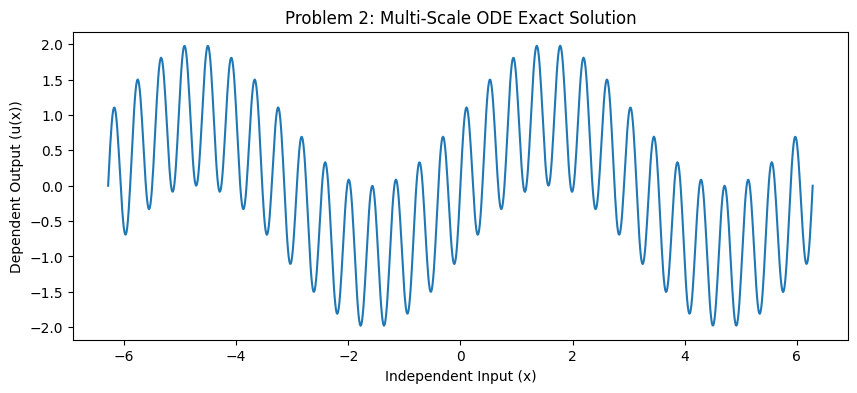

In [21]:
# Plotting exact solution
plt.figure(figsize=(10, 4))
plt.plot(exp3_test_inputs, exp3_test_targets)
plt.xlabel('Independent Input (x)')
plt.ylabel('Dependent Output (u(x))')
plt.title('Problem 2: Multi-Scale ODE Exact Solution')
plt.show()

##### Model Specific Parameter Definitions

In [22]:
# Common parameter definitions
ACTIVATION_FUNCTION = "tanh"
PARAMETER_SAMPLER = "random"
REGULARIZATION_SCALE = 1e-12
SWIM_SVD_CUTOFF= 1e-12
WINDOW_FN = "gaussian"

# SWIM-PDE-DD specific parameter definitions
SWIM_PDE_DD_NUM_BASIS = 5
SWIM_PDE_DD_NUM_SUBDOMAINS = 20
SWIM_PDE_DD_OVERLAPPING_RATIO = 1.9
SWIM_PDE_DD_SOLVER = "lstsq"

# SWIM-PDE specific parameter definitions
SWIM_PDE_NUM_BASIS =  SWIM_PDE_DD_NUM_BASIS * SWIM_PDE_DD_NUM_SUBDOMAINS

##### SWIM-PDE Training and Inference

In [23]:
# Domain Definition
boundary_mask = ((exp3_train_inputs == exp3_train_inputs[0]) | (exp3_train_inputs == exp3_train_inputs[-1])).flatten()
domain = Domain(
        interior_points=exp3_train_inputs[~boundary_mask],
        boundary_points=exp3_train_inputs[boundary_mask],
    )

# Equation Definition
equation = FirstOrder()

# Forcing function and boundary condition definition
forcing_function = partial(prob2_forcing, w1=W1, w2=W2)
boundary_condition = ZeroDirichlet() # u(0) = 0

# Ansatz definition 
ansatz = BasicAnsatz(
    n_basis=SWIM_PDE_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    parameter_sampler=PARAMETER_SAMPLER,
)

# Solver definition
swimpde_solver = StaticSolver(
    domain=domain,
    ansatz=ansatz,
    boundary_condition=boundary_condition,
    equation=equation,
    f=forcing_function, 
    regularization_scale=REGULARIZATION_SCALE,
)

# Training
swimpde_solver.fit()

# Inference
exp3_swimpde_prediction = swimpde_solver.evaluate(exp3_test_inputs).reshape(NUM_TEST_POINTS, -1)

##### SWIM-PDE-DD Training and Inference

In [ ]:
# Domain Definition
boundary_mask = ((exp3_train_inputs == exp3_train_inputs[0]) | (exp3_train_inputs == exp3_train_inputs[-1])).flatten()

domain = DecomposedDomain(
        interior_points=exp3_train_inputs[~boundary_mask],
        boundary_points=exp3_train_inputs[boundary_mask],
        overlap_ratio=SWIM_PDE_DD_OVERLAPPING_RATIO,
        num_partition_per_dim=SWIM_PDE_DD_NUM_SUBDOMAINS,
        window_fn=WINDOW_FN,
    )

# Equation Definition
equation = FirstOrder()

# Forcing function and boundary condition definition
forcing_function = partial(prob2_forcing, w1=W1, w2=W2)
boundary_condition = ZeroDirichlet()

# Ansatz definition 
ansatz = DecomposedBasicAnsatz(
    n_basis=SWIM_PDE_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    svd_cutoff=SWIM_SVD_CUTOFF,
    parameter_sampler=PARAMETER_SAMPLER
)

# Solver definition
swimpde_dd_solver = DomainDecomposedStaticSolver(
    domain=domain,
    ansatz=ansatz,
    boundary_condition=boundary_condition,
    equation=equation,
    f=forcing_function, 
    regularization_scale=REGULARIZATION_SCALE,
    solver=SWIM_PDE_DD_SOLVER,
    use_disk=False,
)

# Inference
exp3_swimpde_dd_prediction, exp3_swimpde_dd_level_based_predictions, exp3_swimpde_dd_local_network_predictions = swimpde_dd_solver.evaluate(exp3_test_inputs)
exp3_swimpde_dd_prediction = exp3_swimpde_dd_prediction.reshape(NUM_TEST_POINTS, -1)

[ True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False Fa

TypeError: 'NoneType' object is not subscriptable

#### Final Prediction Comparison

In [ ]:
# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
axs = axs.flatten()

# Subplot (a): Individual networks
local_predictions = exp3_swimpde_dd_local_network_predictions[0]
for local_prediction in local_predictions:
    axs[0].plot(exp1_test_inputs, local_prediction)
    axs[0].set_title("(a) SWIM-PDE-DD local network predictions")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("u")
    
# Subplot (b): Window functions
window_evals = [subdomain.window_fn.f(exp3_test_inputs) for subdomain in domain.subdomains]
normalizer = np.sum(np.array(window_evals), axis=0)
for window_eval in window_evals:
    axs[1].plot(exp3_test_inputs, window_eval/normalizer)
    axs[1].set_title("(b) SWIM-PDE-DD normalized window function evaluations")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("w(x)")

# Subplot (c): Full solution vs exact
axs[2].plot(exp3_test_inputs, exp3_test_targets, '-', label='Exact', color='black', linewidth=4, alpha=0.5)
axs[2].plot(exp3_test_inputs, exp3_swimpde_prediction, '-.', label='SWIM-PDE', color='blue', linewidth=3)
axs[2].plot(exp3_test_inputs, exp3_swimpde_dd_prediction, '-', dashes=(4, 4), label='SWIM-PDE-DD', color='lime', linewidth=3)
axs[2].set_title("(c) SWIM-PDE and SWIM-PDE-DD predictions")
axs[2].set_xlabel("x")
axs[2].set_ylabel("u")
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Mean L1 Loss (Mean Absolute Error = MAE) comparison
from sklearn.metrics import mean_absolute_error
exp3_swimpde_loss = mean_absolute_error(exp3_test_targets, exp3_swimpde_prediction)
exp3_swimpde_dd_loss = mean_absolute_error(exp3_test_targets, exp3_swimpde_dd_prediction)

print("SWIM-PDE Multi-Scale MAE = ", exp3_swimpde_loss)
print("SWIM-PDE-DD Multi-Scale MAE =", exp3_swimpde_dd_loss)
print("Number of partition =", SWIM_PDE_DD_NUM_SUBDOMAINS)
print("Estimated number of training points per subdomain = ", NUM_TRAIN_POINTS/SWIM_PDE_DD_NUM_SUBDOMAINS)

#### Evaluation

This is the most difficult configuration of the 1D sinusoidal experiments, since we try to approximate a solution which contains two different frequency contents $\omega_1=1$ and $\omega_2=15$. As a result, we can observe that even though the total capacity of the both SWIM-PDE and SWIM-PDE-DD models are the same, SWIM-PDE model can capture only the low frequency content and struggles by capturing the high frequency oscillations (spectral bias), whereas the SWIM-PDE-DD model approximates the solution more accurately by capturing all the dynamics of the solution.

From the figure above, we can see each individual network predictions after the weighting with corresponding window function evaluation is applied in the first subplot. In the second subplot we can see how the normalized window function evaluations cover the entire domain. Finally in the third subplot we can see the global predictions of both models. The global prediction of the SWIM-PDE-DD model is obtained summing of the weighted local network predictions by their normalized window function evaluations over the whole domain. This approach produces a better approximation result by blending each local network prediction which can capture the local dynamics better smoothly make use of the window functions. 